In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_reader import DataReader
from statsmodels.tsa.seasonal import STL
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from datetime import datetime

# 1. Cargar dataset

In [2]:
data_reader = DataReader()
coVar_data, rr_data, tg_data, tn_data, tx_data, master_data = data_reader.read_data().values()
tg_coVar_merged = data_reader.merge_observations_with_coVar(tg_data, coVar_data, 'tg')
ids_list = list(tg_coVar_merged['Id'].unique())

In [5]:
print(ids_list)
print(len(ids_list))

['229', '230', '231', '232', '233', '234', '235', '236', '237', '238', '309', '335', '336', '337', '412', '414', '415', '416', '417', '418', '419', '420', '421', '422', '423', '424', '425', '455', '1388', '1389', '1392', '1393', '1394', '1395', '1396', '1397', '1398', '1399', '1401', '1404', '1405', '1406', '2969', '2970', '3838', '3839', '3903', '3904', '3905', '3906', '3907', '3908', '3909', '3910', '3911', '3912', '3913', '3914', '3915', '3916', '3917', '3918', '3919', '3920', '3921', '3922', '3923', '3924', '3925', '3926', '3927', '3928', '3929', '3930', '3931', '3932', '3933', '3934', '3935', '3937', '3938', '3939', '3940', '3942', '3943', '3944', '3945', '3946', '3947', '3948', '3949', '3950', '3951', '3952', '3953', '3954', '3955', '3956', '3957', '3958', '3959', '3960', '3961', '3962', '3963', '3964', '3965', '3966', '3967', '3968', '3969', '3970', '3971', '10904', '10905', '11009', '11010', '11011', '11012', '11013', '11014', '11015', '11016', '11017', '11018', '11019', '11020

# 2. EDA

In [6]:
tg_coVar_merged.columns

Index(['Year', 'Month', 'Id', 'tg', 'Longitud', 'Latitud', 'topo', 'topo2',
       'topo3', 'DistCosta', 'DistCosta2', 'DistCosta3', 'N', 'NW', 'W', 'SW',
       'S', 'SE', 'E', 'NE', 'distN', 'distNW', 'distW', 'distSW', 'distS',
       'distSE', 'distE', 'distNE', 'aspect', 'slope', 'vcurv', 'hcurv',
       'curv', 'swi'],
      dtype='object')

In [7]:
# 2.1 Estadísticas básicas globales
print(tg_coVar_merged['tg'].describe())

count    275442.000000
mean         15.120218
std           6.445931
min          -9.879310
25%          10.207143
50%          14.980000
75%          20.147957
max          31.580645
Name: tg, dtype: float64


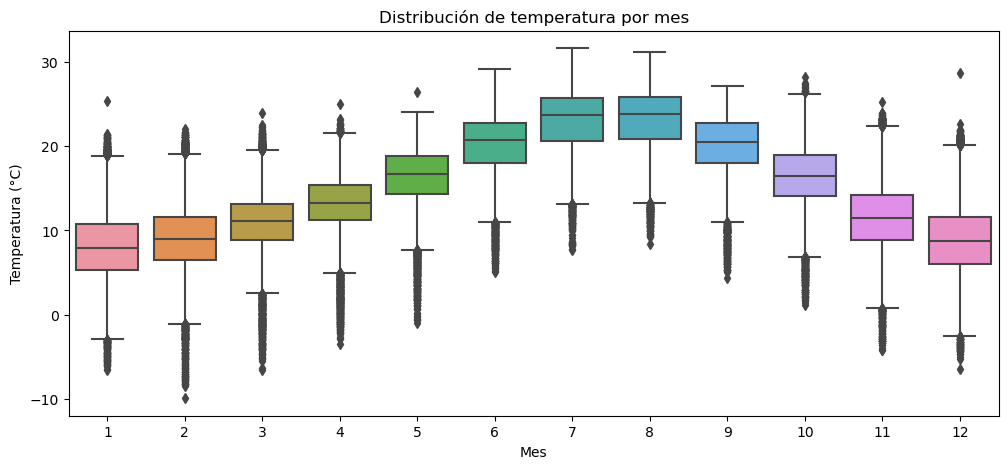

In [8]:
# 2.2 Boxplot mensual
plt.figure(figsize=(12,5))
sns.boxplot(x=tg_coVar_merged['Month'], y=tg_coVar_merged['tg'])
plt.title("Distribución de temperatura por mes")
plt.xlabel("Mes")
plt.ylabel("Temperatura (°C)")
plt.show()

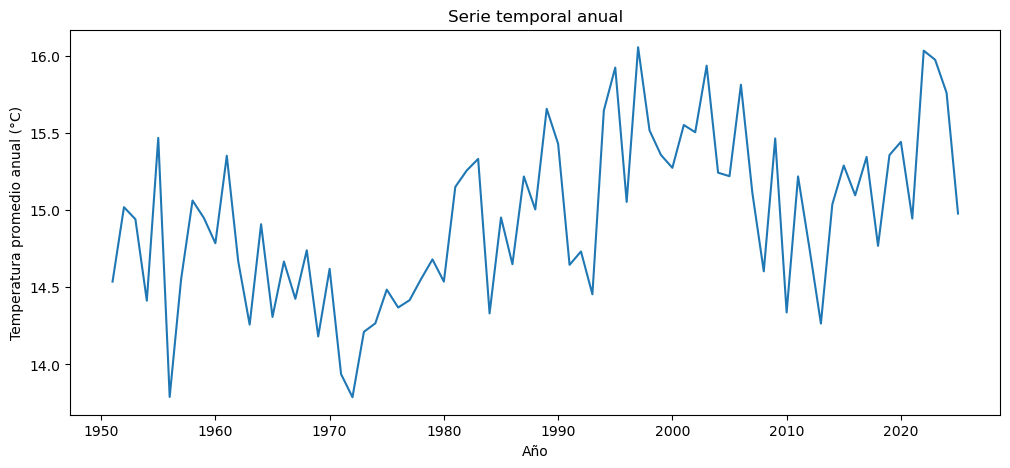

In [9]:
# 2.3 Serie temporal promedio anual
annual_avg = tg_coVar_merged.groupby('Year', sort=True)['tg'].mean()
plt.figure(figsize=(12,5))
annual_avg.plot()
plt.xlabel("Año")
plt.ylabel("Temperatura promedio anual (°C)")
plt.title("Serie temporal anual")
plt.show()

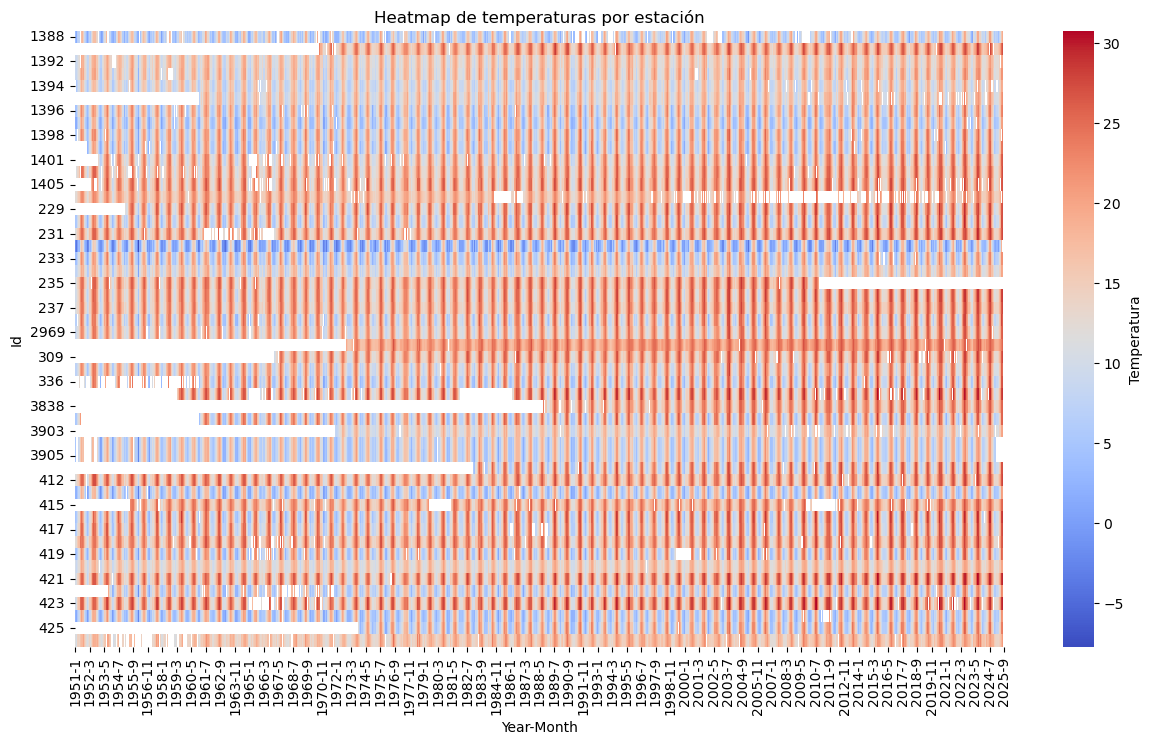

In [10]:
# 2.4 Heatmap de estaciones vs tiempo
subset_ids = tg_coVar_merged['Id'].unique()[:50]
heat_data = tg_coVar_merged[tg_coVar_merged['Id'].isin(subset_ids)].pivot(index='Id', columns=['Year', 'Month'], values='tg')
plt.figure(figsize=(15,8))
sns.heatmap(heat_data, cmap='coolwarm', cbar_kws={'label':'Temperatura'})
plt.title("Heatmap de temperaturas por estación")
plt.show()

# 3. Análisis de correlaciones

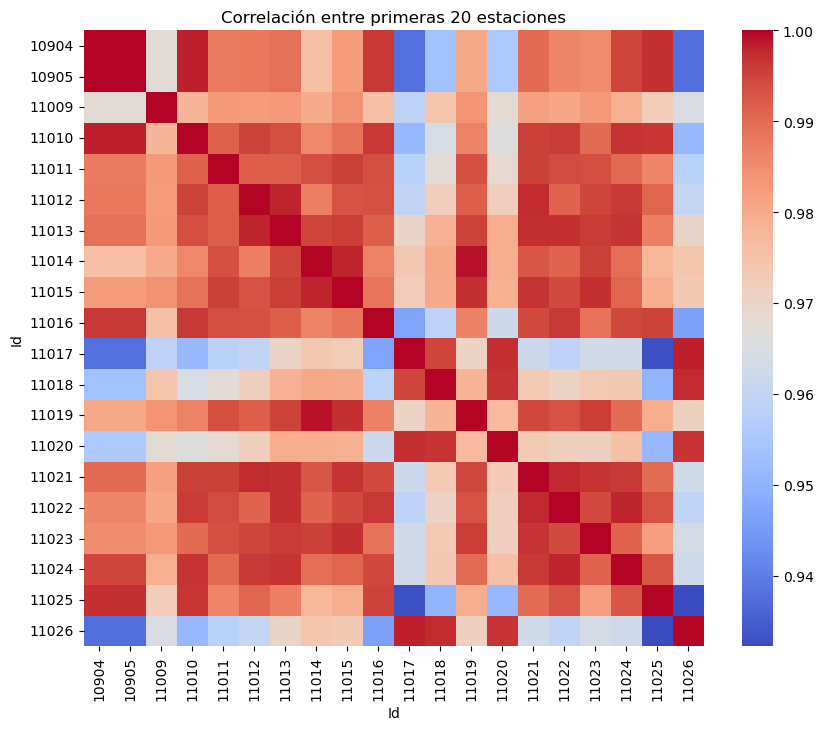

In [11]:
# 3.1 Correlación entre estaciones
pivot_stations = tg_coVar_merged.pivot(index=['Year', 'Month'], columns='Id', values='tg')
corr_stations = pivot_stations.corr(method='pearson')  # matriz de correlación
plt.figure(figsize=(10,8))
sns.heatmap(corr_stations.iloc[:20,:20], cmap='coolwarm', annot=False)
plt.title("Correlación entre primeras 20 estaciones")
plt.show()

In [12]:
# 3.2 Correlación con covariables
# Obtener todas las columnas numéricas (excluyendo las ya usadas)
exclude = ['Id', 'Year', 'Month', 'tg']  # ajusta según tu DataFrame
covariables = [col for col in tg_coVar_merged.select_dtypes(include='number').columns 
               if col not in exclude]

print("Covariables disponibles:", covariables)

Covariables disponibles: ['Longitud', 'Latitud', 'topo', 'topo2', 'topo3', 'DistCosta', 'DistCosta2', 'DistCosta3', 'distN', 'distNW', 'distW', 'distSW', 'distS', 'distSE', 'distE', 'distNE', 'slope', 'vcurv', 'hcurv', 'curv']


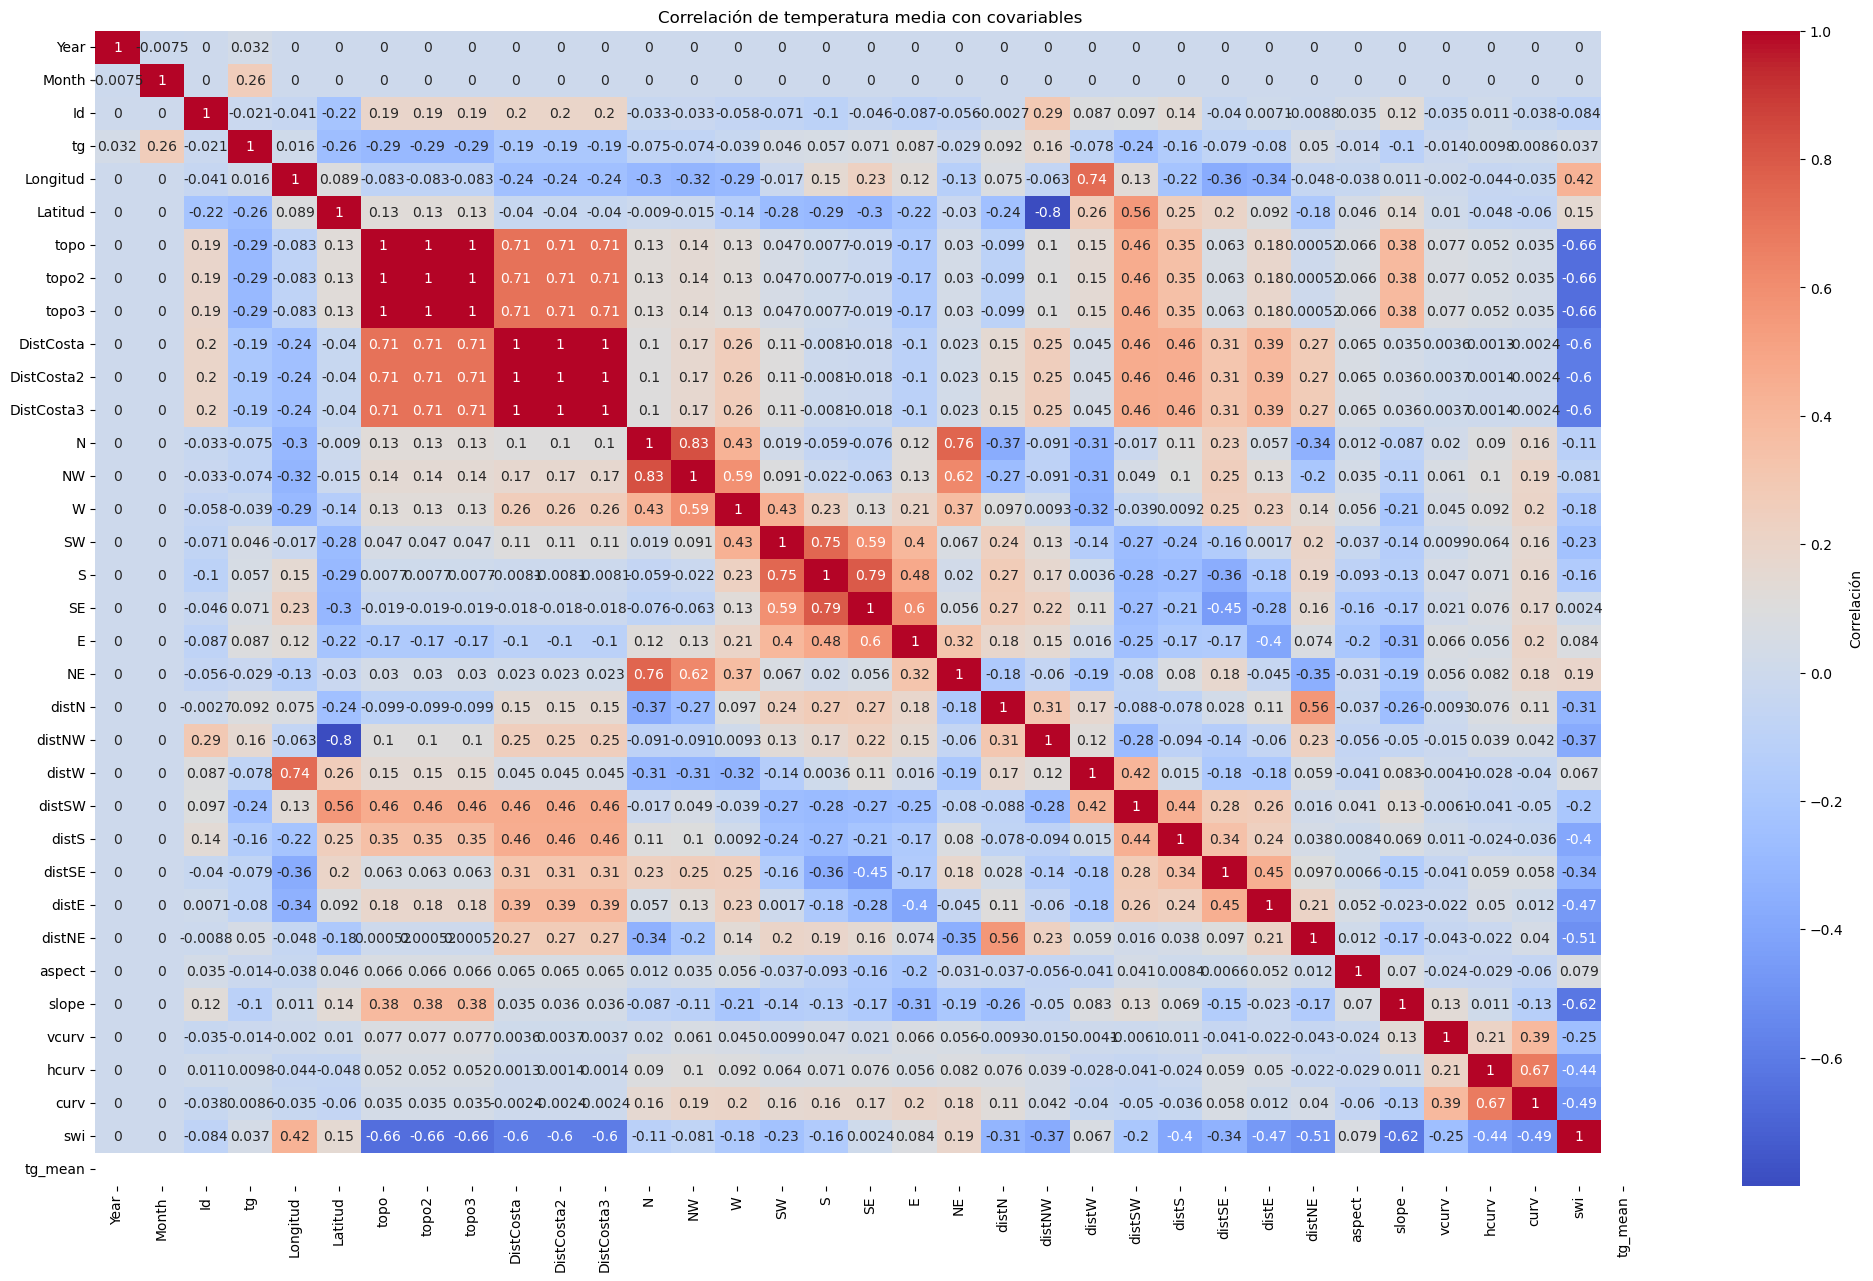

In [15]:
# Ahora usar las covariables detectadas
# df_cov = tg_coVar_merged.drop_duplicates(subset=['Id'])[['Id'] + covariables + ['tg'] + ['Year'] + ['Month']].set_index('Id')
df_cov = tg_coVar_merged.copy()

# Promedio de temperatura por estación (usar 'Id' consistentemente)
temp_mean = tg_coVar_merged.groupby('Id')['tg'].mean()
df_cov['tg_mean'] = temp_mean

# Correlación
corr_cov = df_cov.corr(method='spearman')
plt.figure(figsize=(25, 15))
sns.heatmap(corr_cov, annot=True, cmap='coolwarm', cbar_kws={'label': 'Correlación'})
plt.title("Correlación de temperatura media con covariables")
plt.show()

In [ ]:

# Escalar covariables numéricas
covariables = ['Longitud', 'Latitud', 'topo', 'topo2', 'topo3', 'DistCosta', 'DistCosta2', 'DistCosta3', 'N', 'NW', 'W', 'SW', 'S', 'SE', 'E', 'NE', 'distN', 
               'distNW', 'distW', 'distSW', 'distS', 'distSE', 'distE', 'distNE', 'aspect', 'slope', 'vcurv', 'hcurv', 'curv', 'swi']  # seleccionar covariables de interés
df_cov = tg_coVar_merged.drop_duplicates(subset=['Id'])[['Id'] + covariables + ['tg']].set_index('Id')
# Promedio de temperatura por estación
temp_mean = tg_coVar_merged.groupby('ID')['tg'].mean()
df_cov['tg_mean'] = temp_mean
corr_cov = df_cov.corr(method='spearman')
plt.figure(figsize=(8,6))
sns.heatmap(corr_cov, annot=True, cmap='coolwarm')
plt.title("Correlación de temperatura media con covariables")
plt.show()

In [ ]:
# ---------------------------
# 4. Análisis temporal avanzado
# ---------------------------

# 4.1 Tendencia por estación (regresión lineal simple)
trends = {}
for idx, id_ in enumerate(ids_list):
    temps = temp_matrix[idx,:]
    valid = ~np.isnan(temps)
    if np.sum(valid)<2:
        trends[id_] = np.nan
        continue
    x = np.array([dates_all[i].year for i,v in enumerate(valid) if v])
    y = temps[valid]
    slope, intercept = np.polyfit(x, y, 1)
    trends[id_] = slope  # °C por año

print("Tendencias (°C/año) primeras 10 estaciones:")
for k in list(trends.keys())[:10]:
    print(k, trends[k])

# 4.2 Descomposición sencilla (media móvil para una estación)
window = 12  # meses
station_id = ids_list[0]
temps_series = temp_matrix[id_to_index[station_id],:]
temps_series_ma = np.convolve(np.nan_to_num(temps_series), np.ones(window)/window, mode='valid')

plt.figure(figsize=(12,5))
plt.plot(dates_all, temps_series, label='Original')
plt.plot(dates_all[window-1:], temps_series_ma, label='Media móvil 12 meses', color='red')
plt.title(f"Temperatura mensual estación {station_id}")
plt.ylabel("°C")
plt.legend()
plt.show()

# 4.3 Cálculo de anomalías (base 1951-1980)
base_monthly = [0]*12
for m in range(1,13):
    temps_base = [row['temp'] for row in data if row['year']>=1951 and row['year']<=1980 and row['month']==m and not np.isnan(row['temp'])]
    base_monthly[m-1] = np.mean(temps_base)

anom = []
for row in data:
    if not np.isnan(row['temp']):
        an = row['temp'] - base_monthly[row['month']-1]
        anom.append((row['year'], an))
# Promedio anual de anomalías
anom_years = {}
for y, a in anom:
    anom_years.setdefault(y, []).append(a)
anom_avg = {y:np.mean(v) for y,v in anom_years.items()}

plt.figure(figsize=(12,5))
plt.plot(list(anom_avg.keys()), list(anom_avg.values()))
plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Año")
plt.ylabel("Anomalía (°C)")
plt.title("Anomalía anual promedio respecto 1951-1980")
plt.show()

TypeError: tuple indices must be integers or slices, not str

In [ ]:
# 3.2 Correlación con covariables (topo, slope, distCosta, aspect)
station_cov = []
temp_mean_per_station = []
for id_ in ids_list:
    temps = [row['temp'] for row in data if row['ID']==id_ and not np.isnan(row['temp'])]
    temp_mean_per_station.append(np.mean(temps))
    # tomamos covariables del primer registro
    for row in data:
        if row['ID']==id_:
            station_cov.append([row['topo'], row['slope'], row['distCosta'], row['aspect']])
            break
station_cov = np.array(station_cov)
temp_mean_per_station = np.array(temp_mean_per_station)

corr_cov = np.corrcoef(np.column_stack([temp_mean_per_station, station_cov]).T)
print("Matriz de correlación temperatura media vs covariables:")
print(corr_cov)
